# The Fourth Circle: Neural Networks, Part Four 
## Transformers VI: Swin Transformer

<br/>
Jiří Fejlek

2026-05-08
<br/>

Vision transformers [[1](#1)] demonstrated that the attention-based transformer architectures are successfully applicable for computer vision tasks, especially on large-scale datasets. However, as we have explored in a previous project, there are inherent challenges in directly transferring a transformer designed primarily for natural language processing to vision. Unlike convolutional neural networks (CNNs), transformers lack a strong inductive bias, which means they usually underperform on smaller datasets (when trained from scratch) compared to CNNs [[2](#2)]. In addition, the attention mechanism has quadratic computational complexity, which can be too expensive for high-resolution images. Lastly, vision transformers work in a fixed scale. In the transformer architecture, we can see that the signal dimensions across the transformer blocks remain identical. This is in stark contrast with convolutional neural networks, which process images at various scales; images are progressively downsampled as the number of channels increases from block to block.

Swin transformer [[3](#3)] attempts to bridge these difficulties and provide a general-purpose transformer for vision tasks.


## Table of Contents

- [Swin Transformer](#swin_trans)
    - [Patch Merging](#patch_emb)
    - [Relative Position Bias](#rel_bias)
    - [Window-based Self-Attention](#window)
        - [Self-attention for Non-shifted Windows](#no_shift)
        - [Self-attention for Shifted Windows](#shift)
    - [Implementation](#implementation)
  - [Training Swin Transformer on Fashion-MNIST and CIFAR-10](#training)
  - [Transfer Learning on CIFAR-10](#transfer_learning)
- [References](#references)

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import math

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

## Swin Transformer <a class="anchor" id="swin_trans"></a>

Let us start with a sketch of the  Swin transformer architecture [[3](#3)].

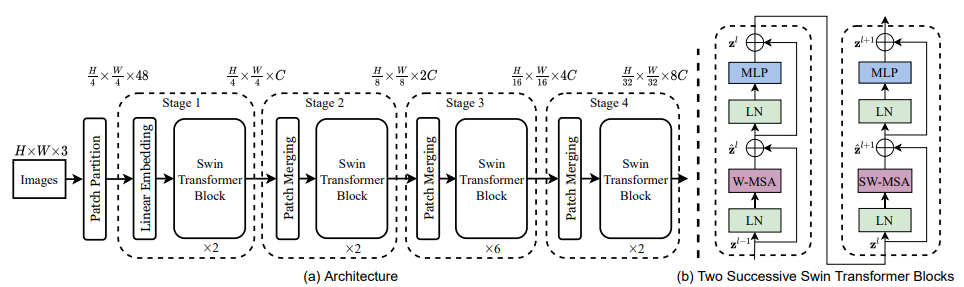

There are several notable differences between the vision transformer and Swin. Most notably, the Swin transformer is *hierarchical*. The images are downsampled after each Swin transformer block, unlike the vision transformer, which uses a single downsampling step at the start when an image is split into patches. Another change is the use of new variants of the multi-head self-attention (MSA) mechanism: window MSA (W-MSA) and shifted window MSA (SW-MSA). In the window and the shifted window MSA, attention is no longer computed globally across the whole image; instead, it is restricted to several local *windows*. This change reduces the computational burden of attention evaluation, making it more suitable for large images. Lastly, the Swin transformer does not use absolute positional embeddings; instead, it uses *relative position bias* [[3](#3)].   

Let us go through all three elements in more detail. The implementation presented here is based on the one from PyTorch https://docs.pytorch.org/vision/main/models/swin_transformer.html.

### Patch Merging <a class="anchor" id="patch_emb"></a>

Let us start with the patch merging layer that is used to downsample patches between Swin transformer blocks [[3](#3)]. 

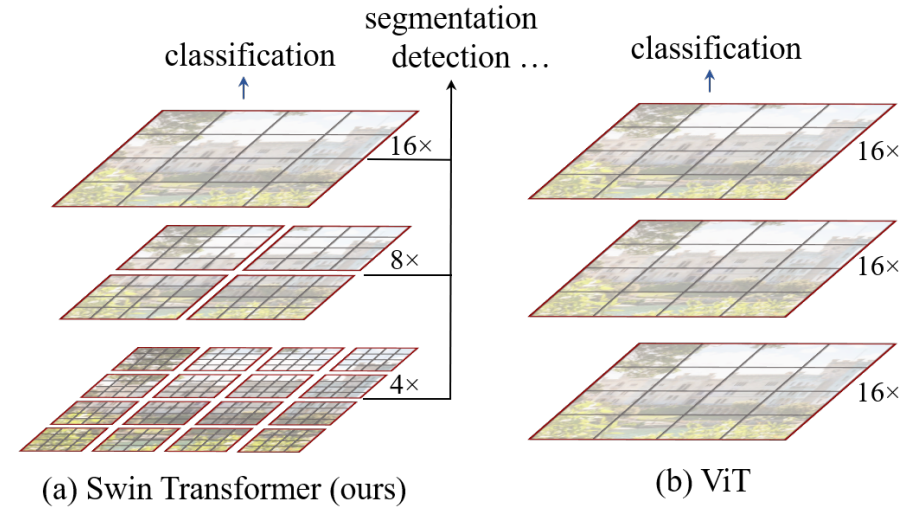

As shown in the sketches, the number of patches is halved, whereas the number of channels (i.e., the dimensionality of the patch embedding) is doubled. In https://docs.pytorch.org/vision/main/models/swin_transformer.html, the patch-merging implementation is pretty straightforward. We first pad the "patched" image to even width and height using *F.pad*.

In [3]:
def _patch_merging_pad(x):
    H, W, _ = x.shape[-3:]
    x = F.pad(x, (0, 0, 0, W % 2, 0, H % 2)) # padding to even H, W
    x0 = x[..., 0::2, 0::2, :]  # ... H/2 W/2 C
    x1 = x[..., 1::2, 0::2, :]  # ... H/2 W/2 C
    x2 = x[..., 0::2, 1::2, :]  # ... H/2 W/2 C
    x3 = x[..., 1::2, 1::2, :]  # ... H/2 W/2 C
    x = torch.cat([x0, x1, x2, x3], -1)  # ... H/2 W/2 4*C
    return x

In [4]:
X = torch.zeros(250, 29, 29, 3)
H, W, _ = X.shape[-3:]
X = F.pad(X, (0, 0, 0, W % 2, 0, H % 2))
X.size()

torch.Size([250, 30, 30, 3])

Then we downsample the images in four ways by selecting odd/even rows and columns, and concatenate the results.

In [5]:
[0, 1, 2, 3, 4, 5][0::2]

[0, 2, 4]

In [6]:
[0, 1, 2, 3, 4, 5][1::2]

[1, 3, 5]

In [7]:
x0 = X[..., 0::2, 0::2, :]
x0.size()

torch.Size([250, 15, 15, 3])

Overall, we get the images of half the width and height with four times as many channels.

In [8]:
x0 = X[..., 0::2, 0::2, :]  # ... H/2 W/2 C
x1 = X[..., 1::2, 0::2, :]  # ... H/2 W/2 C
x2 = X[..., 0::2, 1::2, :]  # ... H/2 W/2 C
x3 = X[..., 1::2, 1::2, :]
torch.cat([x0, x1, x2, x3], -1).size()

torch.Size([250, 15, 15, 12])

In [9]:
_patch_merging_pad(X).size()

torch.Size([250, 15, 15, 12])

Since we want to merely double the number of channels, we will apply a linear layer (that is followed by a layer normalization).

In [10]:
class PatchMerging(nn.Module):

    def __init__(self, dim): # dim: number of input channels
        super().__init__()
        self.dim = dim 
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):

        x = _patch_merging_pad(x) # ... H/2 W/2 4*C
        x = self.norm(x)
        x = self.reduction(x)  # ... H/2 W/2 2*C
        return x

In [11]:
patch_merg = PatchMerging(dim = 3)

In [12]:
X = torch.zeros(250, 29, 29, 3)
patch_merg(X).size()

torch.Size([250, 15, 15, 6])

### Relative Position Bias <a class="anchor" id="rel_bias"></a>

As we mentioned at the beginning, the Swin transformer does not use absolute positional embeddings; instead, it uses an attention mechanism with *relative position bias*. Let $M$ be the number of patches, $d$ be the query/key dimension. Attention with relative position bias $B \in \mathbb{R}^{M^2 \times M^2}$ is computed as
$$ \text{Attention }(Q,K,V) = \text{SoftMax}(QK^T/\sqrt{d} + B)V,$$
where $Q, K,V \in \mathbb{R}^{M^2 \times d}$ are queries, keys, and values respectively. Relative position bias $B$ is given by a relative position bias table $\hat{B} \in \mathbb{R}^{(2M-1) \times (2M-1)}$ which encodes relative positional information between patches (the values in the table are learnable parameters). 

The relative position bias table $\hat{B}$ is probably best understood from the example; see the figure below (from https://medium.com/@ovularslan/breaking-down-swin-transformer-understanding-relative-position-bias-and-masked-self-attention-437d692ab7cf).

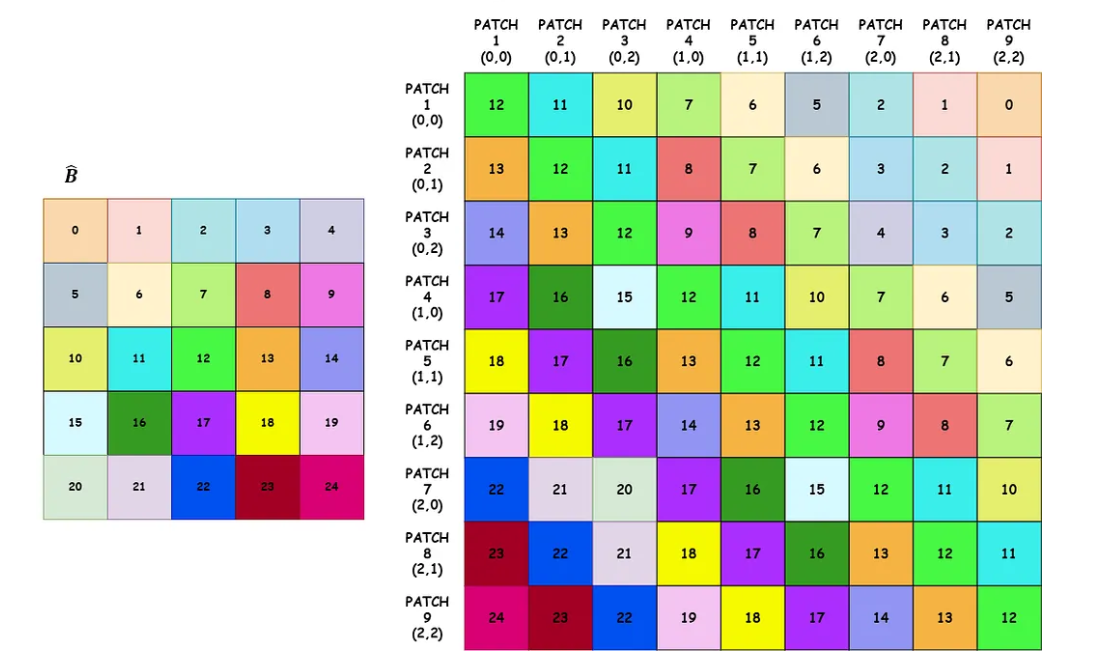

The central element in $\hat{B}$ (12) denotes $(0,0)$ bias, i.e., it corresponds to the self-attention $(0,0)$, $(1,1)$, etc. The other elements correspond to the relative shift with respect to the central element (a shift in rows corresponds to the first dimension, a shift in columns to the second dimension). Hence, the relative position bias between $(0,0)$ and $(1,0)$ is 7 and 17 (depending whether we compute $\alpha((0,0), (0,1))$ or $\alpha((0,1), (0,0))$), between $(0,0)$ and $(0,1)$ is 11 and 13, and between $(0,0)$ and $(1,1)$ is 6 and 18, etc. 

Let us show how the relative position bias $B$ is computed in https://docs.pytorch.org/vision/main/models/swin_transformer.html. For simplicity's sake, let us assume a single-head attention mechanism. We will assume that the image is split into 9 patches (the same number as in the figure). 

First, we need to generate the relative position bias table $\hat{B}$ (in a mode, the specific values would be learnable parameters).

In [13]:
torch.manual_seed(123)

# generate relative_position_bias_table weights as a tensor (2N-1 * 2N-1, 1)
image_size = [3, 3]
relative_position_bias_table = torch.arange((2 * image_size[0] - 1) * (2 * image_size[1] - 1))[:, None]

relative_position_bias_table.size()

torch.Size([25, 1])

In [14]:
torch.round(relative_position_bias_table.view(5,5))

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24]])

Next, we generate coordinates tensors for patches ($x = 0, \ldots, 4$, $y = 0, \ldots, 4 $).

In [15]:
coords_h = torch.arange(image_size[0])
coords_w = torch.arange(image_size[1])
coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))
coords = torch.flatten(coords, 1)
coords

tensor([[0, 0, 0, 1, 1, 1, 2, 2, 2],
        [0, 1, 2, 0, 1, 2, 0, 1, 2]])

We can obtain the relative coordinates as follows.

In [16]:
relative_coords = coords[:, :, None] - coords[:, None, :]
relative_coords

tensor([[[ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0]],

        [[ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0],
         [ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0],
         [ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0]]])

These are indeed relative coordinates. For example, the 1st patch from the 1st patch (2nd from the 2nd, etc.) is zero, as expected.

In [17]:
relative_coords[:, 0, 0]

tensor([0, 0])

In [18]:
relative_coords[:, 4, 4]

tensor([0, 0])

The first patch from the third one is two points in one dimension.

In [19]:
relative_coords[:, 2, 0]

tensor([0, 2])

The first patch from the fourth one is one point in the other dimension (the fourth patch is below the first patch in 3x3 image).

In [20]:
relative_coords[:, 3, 0]

tensor([1, 0])

The fifth one is diagonally adjacent to the first, so its relative position is (1, 1).

In [21]:
relative_coords[:, 4, 0]

tensor([1, 1])

The relative position of the corners is as follows.

In [22]:
relative_coords[:, 8, 0]

tensor([2, 2])

In [23]:
relative_coords[:, 6, 2]

tensor([ 2, -2])

Now, the hardest step is to obtain the matrix $B$ (the second matrix in the figure) from $\hat{B}$ and the tensor of relative positions. It is probably not necessary to go step by step. The computations in https://docs.pytorch.org/vision/main/models/swin_transformer.html are as follows.

In [24]:
relative_coords = relative_coords.permute(1, 2, 0).contiguous()
relative_coords[:, :, 0] += image_size[0] - 1 
relative_coords[:, :, 1] += image_size[1] - 1
relative_coords[:, :, 0] *= 2*image_size[1] - 1
relative_position_index = relative_coords.sum(-1).flatten()

def _get_relative_position_bias(relative_position_bias_table, relative_position_index, image_size):
    N = image_size[0] * image_size[1]
    relative_position_bias = relative_position_bias_table[relative_position_index]
    relative_position_bias = relative_position_bias.view(N, N, -1)
    relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous().unsqueeze(0)
    return relative_position_bias

We can check that the matrix corresponds to the figure from https://medium.com/@ovularslan/breaking-down-swin-transformer-understanding-relative-position-bias-and-masked-self-attention-437d692ab7cf.

In [25]:
rel_bias = _get_relative_position_bias(relative_position_bias_table,relative_position_index, [3, 3])
rel_bias

tensor([[[[12, 11, 10,  7,  6,  5,  2,  1,  0],
          [13, 12, 11,  8,  7,  6,  3,  2,  1],
          [14, 13, 12,  9,  8,  7,  4,  3,  2],
          [17, 16, 15, 12, 11, 10,  7,  6,  5],
          [18, 17, 16, 13, 12, 11,  8,  7,  6],
          [19, 18, 17, 14, 13, 12,  9,  8,  7],
          [22, 21, 20, 17, 16, 15, 12, 11, 10],
          [23, 22, 21, 18, 17, 16, 13, 12, 11],
          [24, 23, 22, 19, 18, 17, 14, 13, 12]]]])

### Window-based Self-Attention <a class="anchor" id="window"></a>

Global self-attention scales quadratically with the number of patches, making it unsuitable for high-resolution images.  To reduce computational complexity, the Swin transformer reduces self-attention computations to non-overlapping windows. Since this window-based self-attention mechanism lacks connections across windows, the Swin transformer alternates between two window configurations, as shown in the following figure [[3](#3)].

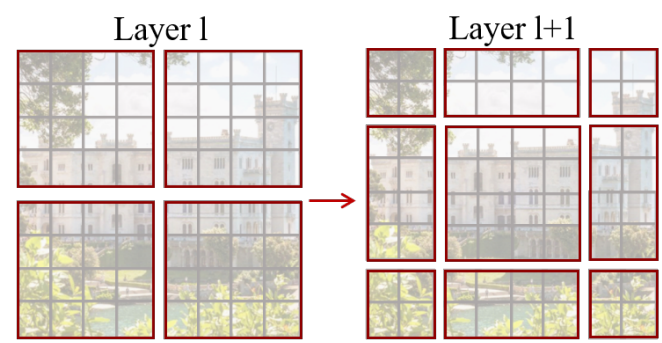

We observe from the figure that the second window configuration can be derived from the first by shifting the window grid by 2 patches in both directions (by half of the window size in general). Thus, the second window configuration is known as *shifted window* self-attention.

#### Self-attention for Non-shifted Windows <a class="anchor" id="no_shift"></a> 

Let us start with the first window configuration, i.e., without a shift. As shown in the figure, we assume the image consists of 8x8 patches, which are split into four 4x4 windows. Let us denote the patches as follows.

In [26]:
patches = torch.arange(64).view(8,8)
patches

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29, 30, 31],
        [32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47],
        [48, 49, 50, 51, 52, 53, 54, 55],
        [56, 57, 58, 59, 60, 61, 62, 63]])

We will also add the batch and channel dimensions by repeating the matrix in these dimensions.

In [27]:
patches = patches[None,:,:,None]
patches = patches.repeat(250,1,1,27)
patches.size()

torch.Size([250, 8, 8, 27])

In [28]:
B, H, W, C = patches.shape

Let us partition the patches into separate windows.

In [29]:
window_size = [4,4]
window_size

[4, 4]

In [30]:
num_windows = (H // window_size[0]) * (W // window_size[1])
num_windows

4

In [31]:
partition_patches = patches.view(B, H // window_size[0], window_size[0], W // window_size[1], window_size[1], C)
partition_patches.size() # batch_size x num_windows0 x window_size0 x num_windows1 x window_size1 x num_channels

torch.Size([250, 2, 4, 2, 4, 27])

We can check that the partition is correct.

In [32]:
partition_patches[0,0,:,0,:,0].view(4,4)

tensor([[ 0,  1,  2,  3],
        [ 8,  9, 10, 11],
        [16, 17, 18, 19],
        [24, 25, 26, 27]])

In [33]:
partition_patches[0,0,:,1,:,0].view(4,4)

tensor([[ 4,  5,  6,  7],
        [12, 13, 14, 15],
        [20, 21, 22, 23],
        [28, 29, 30, 31]])

In [34]:
partition_patches[0,1,:,0,:,0].view(4,4)

tensor([[32, 33, 34, 35],
        [40, 41, 42, 43],
        [48, 49, 50, 51],
        [56, 57, 58, 59]])

In [35]:
partition_patches[0,1,:,1,:,0].view(4,4)

tensor([[36, 37, 38, 39],
        [44, 45, 46, 47],
        [52, 53, 54, 55],
        [60, 61, 62, 63]])

Now, we can compute multi-head attention on each window. Since we are using multi-head attention with a relative position bias, we first compute the relative position bias matrix $B$.

In [36]:
num_heads = 3

#relative position bias
window_size = [4, 4]
relative_position_bias_table = nn.Parameter(torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads))
nn.init.trunc_normal_(relative_position_bias_table, std=0.02)

coords_h = torch.arange(window_size[0])
coords_w = torch.arange(window_size[1])
coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij")) 
coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  
relative_coords = relative_coords.permute(1, 2, 0).contiguous() 
relative_coords[:, :, 0] += window_size[0] - 1  
relative_coords[:, :, 1] += window_size[1] - 1
relative_coords[:, :, 0] *= 2 * window_size[1] - 1
relative_position_index = relative_coords.sum(-1).flatten()

relative_position_bias = _get_relative_position_bias(relative_position_bias_table, relative_position_index, window_size)
relative_position_bias.size() # 1 x num_heads x num_patches_window x num_patch_window 

torch.Size([1, 3, 16, 16])

Next, we need to compute keys/queries/values. These are obtained from the patch embeddings via a linear layer. 

In [37]:
qkv_linear_layer = nn.Linear(C, C*3)  # linear layer that projects patches into keys/values/queries

In [38]:
partition_patches = partition_patches.permute(0, 1, 3, 2, 4, 5).reshape(B * num_windows, window_size[0] * window_size[1], C)
qkv = qkv_linear_layer(partition_patches.float())
qkv.size() #batch_size*num_windows x num_patches_window x 3*num_channles

torch.Size([1000, 16, 81])

Next, we need to reshape the *qkv* tensor to efficiently compute the attention values for each window/attention head. The code in https://docs.pytorch.org/vision/main/models/swin_transformer.html is as follows.

In [39]:
qkv = qkv.reshape(partition_patches.size(0), partition_patches.size(1), 3, num_heads, C // num_heads).permute(2, 0, 3, 1, 4)
qkv.size() # 3 x batch_size*num_windows x num_heads x num_patches_window x channel_size/num_heads

torch.Size([3, 1000, 3, 16, 9])

In [40]:
q, k, v = qkv[0], qkv[1], qkv[2]
q = q * (C // num_heads) ** -0.5
attn = q.matmul(k.transpose(-2, -1)) + relative_position_bias
attn.size() # batch_size*num_windows x  num_heads x window_size x window_size

torch.Size([1000, 3, 16, 16])

The final steps are the same as for global multi-head attention: we apply a softmax layer, multiply the results by the values, and concatenate the results. 

In [41]:
attn_final = F.softmax(attn, dim=-1).matmul(v).transpose(1, 2).reshape(partition_patches.size(0), partition_patches.size(1), C)
attn_final.size()

torch.Size([1000, 16, 27])

Lastly, we apply the final linear layer. We also need to reshape the result into the original shape *batch_size x patches_size0 x patches_size1 x num_channels*.

In [42]:
proj_linear_layer = nn.Linear(C, C, bias = False)
attn_final = proj_linear_layer(attn_final)

# reverse transformations
attn_final = attn_final.view(B, H // window_size[0], W // window_size[1], window_size[0], window_size[1], C)
attn_final = attn_final.permute(0, 1, 3, 2, 4, 5).reshape(B, H, W, C)

In [43]:
attn_final.size() # batch_size x patches_size0 x patches_size1 x num_channels

torch.Size([250, 8, 8, 27])

#### Self-attention for Shifted Windows <a class="anchor" id="shift"></a> 

Self-attention for shifted windows is a bit more involved. The major obstacle is that the shifted windows vary in size, and we need an approach that is parallelizable for batch computations. One could consider computing attention the same way as in the previous case by padding the image, but that would be unnecessarily computationally expensive [[3](#3)].

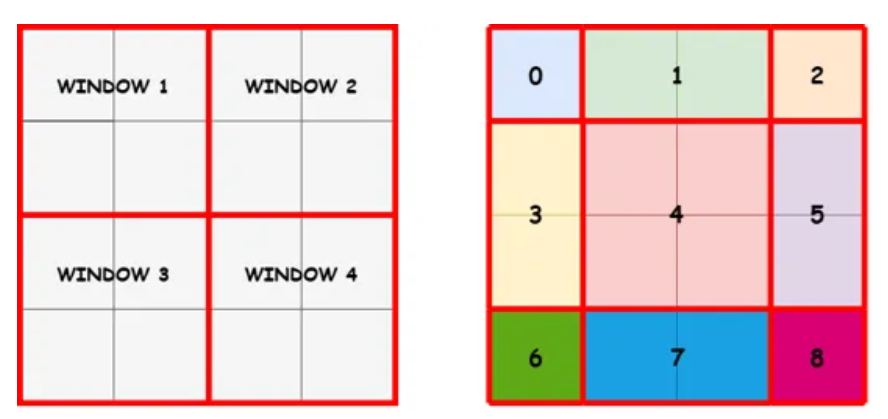

Instead, the authors of [[3](#3)] proposed a clever trick, a *cyclic shifting*.

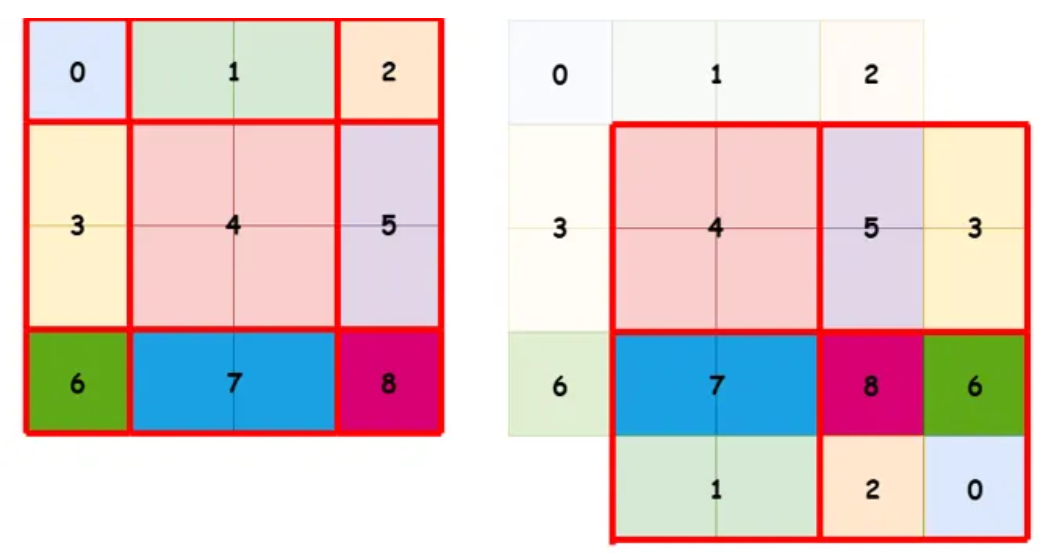

By rearranging the elements of the image, we can now consider computing the same self-attention as for non-shifted (in our example, 4x4) windows, with an additional masking to account for the fact that 3 windows are further split into subwindows.

The cyclic shift is implemented in PyTorch using the *roll* function.*

In [44]:
torch.arange(64).view(8,8)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29, 30, 31],
        [32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47],
        [48, 49, 50, 51, 52, 53, 54, 55],
        [56, 57, 58, 59, 60, 61, 62, 63]])

In [45]:
shift_size = [2,2] # windows_size/2

rotated_patches = torch.roll(patches, shifts=(-shift_size[0], -shift_size[1]), dims=(1, 2)) 
rotated_patches[0,:,:,0]

tensor([[18, 19, 20, 21, 22, 23, 16, 17],
        [26, 27, 28, 29, 30, 31, 24, 25],
        [34, 35, 36, 37, 38, 39, 32, 33],
        [42, 43, 44, 45, 46, 47, 40, 41],
        [50, 51, 52, 53, 54, 55, 48, 49],
        [58, 59, 60, 61, 62, 63, 56, 57],
        [ 2,  3,  4,  5,  6,  7,  0,  1],
        [10, 11, 12, 13, 14, 15,  8,  9]])

To compute the self-attention values, we need to compute the correct masks. Remember that the attention values are subsequently normalized using a softmax layer; thus, adding a large negative value to the dot products makes the corresponding attention values zero. The attention masks are computed in https://docs.pytorch.org/vision/main/models/swin_transformer.html as follows.

In [46]:
# generate attention mask
attn_mask = partition_patches.new_zeros((H, W))
h_slices = ((0, -window_size[0]), (-window_size[0], -shift_size[0]), (-shift_size[0], None))
w_slices = ((0, -window_size[1]), (-window_size[1], -shift_size[1]), (-shift_size[1], None))
count = 0
for h in h_slices:
    for w in w_slices:
        attn_mask[h[0] : h[1], w[0] : w[1]] = count
        count += 1
attn_mask = attn_mask.view(H // window_size[0], window_size[0], W // window_size[1], window_size[1])
attn_mask = attn_mask.permute(0, 2, 1, 3).reshape(num_windows, window_size[0] * window_size[1])
attn_mask = attn_mask.unsqueeze(1) - attn_mask.unsqueeze(2)
attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))

In [47]:
attn_mask.size() # num_windows x num_patches_window x num_patches_window

torch.Size([4, 16, 16])

Let us just check the results.

In [48]:
attn_mask[0,:,:].long()

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [49]:
attn_mask[1,:,:].long()//100

tensor([[ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0],
        [ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0],
        [ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0],
        [ 0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -

In [50]:
attn_mask[2,:,:].long()//100

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -

In [51]:
attn_mask[3,:,:].long()//100

tensor([[ 0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1,  0,  0, -1, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0, -1, -1,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0, -1, -1,  0,  0],
        [-1, -1, -1, -1, -1, -1, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -

The first mask is a zero matrix, since the first window has no subwindows. The other windows are split, and hence, masking is needed. We should note that we represented the large negative values with -1 to make the output more readable. Now, we need to remember that these attention masks are 16x16 matrices; i.e., the rows correspond to the attention masks for individual patches. To get a more natural representation of these masks, let us look at some rows reshaped into 4x4 matrices.

In [52]:
(attn_mask[1,0,:].long()//100).view([4,4])

tensor([[ 0,  0, -1, -1],
        [ 0,  0, -1, -1],
        [ 0,  0, -1, -1],
        [ 0,  0, -1, -1]])

In [53]:
(attn_mask[1,2,:].long()//100).view([4,4])

tensor([[-1, -1,  0,  0],
        [-1, -1,  0,  0],
        [-1, -1,  0,  0],
        [-1, -1,  0,  0]])

In [54]:
(attn_mask[2,0,:].long()//100).view([4,4])

tensor([[ 0,  0,  0,  0],
        [ 0,  0,  0,  0],
        [-1, -1, -1, -1],
        [-1, -1, -1, -1]])

In [55]:
(attn_mask[2,8,:].long()//100).view([4,4])

tensor([[-1, -1, -1, -1],
        [-1, -1, -1, -1],
        [ 0,  0,  0,  0],
        [ 0,  0,  0,  0]])

In [56]:
(attn_mask[3,0,:].long()//100).view([4,4])

tensor([[ 0,  0, -1, -1],
        [ 0,  0, -1, -1],
        [-1, -1, -1, -1],
        [-1, -1, -1, -1]])

In [57]:
(attn_mask[3,3,:].long()//100).view([4,4])

tensor([[-1, -1,  0,  0],
        [-1, -1,  0,  0],
        [-1, -1, -1, -1],
        [-1, -1, -1, -1]])

In [58]:
(attn_mask[3,8,:].long()//100).view([4,4])

tensor([[-1, -1, -1, -1],
        [-1, -1, -1, -1],
        [ 0,  0, -1, -1],
        [ 0,  0, -1, -1]])

In [59]:
(attn_mask[3,10,:].long()//100).view([4,4])

tensor([[-1, -1, -1, -1],
        [-1, -1, -1, -1],
        [-1, -1,  0,  0],
        [-1, -1,  0,  0]])

We can clearly observe that these attention masks indeed correspond to the correct subwindows. As we have mentioned earlier, the shifted attention values will now be computed the same way as the non-shifted ones (for the image with rearranged patches), with the only difference being that we need to add attention masks to the values before applying the softmax layer.

In [60]:
attn = attn.view(partition_patches.size(0) // num_windows, num_windows, num_heads, partition_patches.size(1), partition_patches.size(1))
attn = attn + attn_mask.unsqueeze(1).unsqueeze(0)
attn = attn.view(-1, num_heads, partition_patches.size(1), partition_patches.size(1))
attn.size()

torch.Size([1000, 3, 16, 16])

### Implementation <a class="anchor" id="implementation"></a>

We can now put everything together and obtain an implementation of the Swin Transformer using  the code from https://docs.pytorch.org/vision/main/models/swin_transformer.html.

In [61]:
# patch merging
def _patch_merging_pad(x):
    
    H, W, _ = x.shape[-3:]
    x = F.pad(x, (0, 0, 0, W % 2, 0, H % 2))
    x0 = x[..., 0::2, 0::2, :]  # ... H/2 W/2 C
    x1 = x[..., 1::2, 0::2, :]  # ... H/2 W/2 C
    x2 = x[..., 0::2, 1::2, :]  # ... H/2 W/2 C
    x3 = x[..., 1::2, 1::2, :]  # ... H/2 W/2 C
    x = torch.cat([x0, x1, x2, x3], -1)  # ... H/2 W/2 4*C
    return x

class PatchMerging(nn.Module):

    def __init__(self, dim): # dim: number of input channels
        super().__init__()
        self.dim = dim 
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):

        x = _patch_merging_pad(x) # ... H/2 W/2 4*C
        x = self.norm(x)
        x = self.reduction(x)  # ... H/2 W/2 2*C
        return x

In [62]:
# relative position bias
def _get_relative_position_bias(relative_position_bias_table, relative_position_index, window_size):
    N = window_size[0] * window_size[1]
    relative_position_bias = relative_position_bias_table[relative_position_index]
    relative_position_bias = relative_position_bias.view(N, N, -1)
    relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous().unsqueeze(0)
    return relative_position_bias

In [63]:
# shifted window attention

def shifted_window_attention(input, qkv_weight, proj_weight, relative_position_bias, window_size, num_heads, shift_size, attention_dropout, dropout, qkv_bias = None, proj_bias = None, training = True):
    
    B, H, W, C = input.shape
    
    # Pad feature maps to multiples of window size
    pad_r = (window_size[1] - W % window_size[1]) % window_size[1]
    pad_b = (window_size[0] - H % window_size[0]) % window_size[0]
    x = F.pad(input, (0, 0, 0, pad_r, 0, pad_b))
    _, pad_H, pad_W, _ = x.shape

    shift_size = shift_size.copy()
    # If the window size is larger than the feature size, there is no need to shift the window
    if window_size[0] >= pad_H:
        shift_size[0] = 0
    if window_size[1] >= pad_W:
        shift_size[1] = 0

    # Cyclic shift
    if sum(shift_size) > 0:
        x = torch.roll(x, shifts=(-shift_size[0], -shift_size[1]), dims=(1, 2))

    # Windows partition
    num_windows = (pad_H // window_size[0]) * (pad_W // window_size[1])
    x = x.view(B, pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1], C)
    x = x.permute(0, 1, 3, 2, 4, 5).reshape(B * num_windows, window_size[0] * window_size[1], C)  # B*nW, Ws*Ws, C

    # Multi-head attention
    if qkv_bias is not None:
        qkv_bias = qkv_bias.clone()
        length = qkv_bias.numel() // 3
        qkv_bias[length : 2 * length].zero_()
        
    qkv = F.linear(x, qkv_weight, qkv_bias)
    qkv = qkv.reshape(x.size(0), x.size(1), 3, num_heads, C // num_heads).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]
    q = q * (C // num_heads) ** -0.5
    attn = q.matmul(k.transpose(-2, -1))
    
    attn = attn + relative_position_bias # add relative position bias

    if sum(shift_size) > 0:
        
        # generate attention mask
        attn_mask = x.new_zeros((pad_H, pad_W))
        h_slices = ((0, -window_size[0]), (-window_size[0], -shift_size[0]), (-shift_size[0], None))
        w_slices = ((0, -window_size[1]), (-window_size[1], -shift_size[1]), (-shift_size[1], None))
        count = 0
        for h in h_slices:
            for w in w_slices:
                attn_mask[h[0] : h[1], w[0] : w[1]] = count
                count += 1
        attn_mask = attn_mask.view(pad_H // window_size[0], window_size[0], pad_W // window_size[1], window_size[1])
        attn_mask = attn_mask.permute(0, 2, 1, 3).reshape(num_windows, window_size[0] * window_size[1])
        attn_mask = attn_mask.unsqueeze(1) - attn_mask.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        attn = attn.view(x.size(0) // num_windows, num_windows, num_heads, x.size(1), x.size(1))
        attn = attn + attn_mask.unsqueeze(1).unsqueeze(0)
        attn = attn.view(-1, num_heads, x.size(1), x.size(1))

    attn = F.softmax(attn, dim=-1)
    attn = F.dropout(attn, p=attention_dropout, training=training)

    x = attn.matmul(v).transpose(1, 2).reshape(x.size(0), x.size(1), C)
    x = F.linear(x, proj_weight, proj_bias)
    x = F.dropout(x, p=dropout, training=training)

    # reverse windows
    x = x.view(B, pad_H // window_size[0], pad_W // window_size[1], window_size[0], window_size[1], C)
    x = x.permute(0, 1, 3, 2, 4, 5).reshape(B, pad_H, pad_W, C)

    # reverse cyclic shift
    if sum(shift_size) > 0:
        x = torch.roll(x, shifts=(shift_size[0], shift_size[1]), dims=(1, 2))

    # unpad features
    x = x[:, :H, :W, :].contiguous()
    return x


class ShiftedWindowAttention(nn.Module):
    
    def __init__(self, dim, window_size, shift_size, num_heads, qkv_bias = True, proj_bias = True, attention_dropout = 0.0, dropout = 0.0):
        
        super().__init__()
        self.window_size = window_size
        self.shift_size = shift_size
        self.num_heads = num_heads
        self.attention_dropout = attention_dropout
        self.dropout = dropout

        self.qkv = nn.Linear(dim, dim * 3, bias = qkv_bias)
        self.proj = nn.Linear(dim, dim, bias = proj_bias)

        self.define_relative_position_bias_table()
        self.define_relative_position_index()

    def define_relative_position_bias_table(self):
        
        # define a parameter table of relative position bias
        self.relative_position_bias_table = nn.Parameter(torch.zeros((2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1), self.num_heads))  # 2*Wh-1 * 2*Ww-1, nH
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

    def define_relative_position_index(self):
        
        # get pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))  
        coords_flatten = torch.flatten(coords, 1) 
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  
        relative_coords[:, :, 0] += self.window_size[0] - 1  
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1).flatten()  
        self.register_buffer("relative_position_index", relative_position_index)

    def get_relative_position_bias(self):
        return _get_relative_position_bias(self.relative_position_bias_table, self.relative_position_index, self.window_size)

    def forward(self, x):
        
        relative_position_bias = self.get_relative_position_bias()
        return shifted_window_attention(
            x,
            self.qkv.weight,
            self.proj.weight,
            relative_position_bias,
            self.window_size,
            self.num_heads,
            shift_size = self.shift_size,
            attention_dropout = self.attention_dropout,
            dropout = self.dropout,
            qkv_bias = self.qkv.bias,
            proj_bias = self.proj.bias,
            training = self.training,
        )

The Swin transformer block consists of a non-shifted window-based attention layer followed by a shifted one. We should also note that the implementation in https://docs.pytorch.org/vision/main/models/swin_transformer.html also included stochastic depth [[4](#4)], which we discussed in the project dedicated to ResNet. In short, stochastic depth allows the signal to skip blocks with a given probability during training and serves as an additional regularization technique akin to dropout.

In [64]:
# Swin transformer block

class SwinTransformerBlock(nn.Module):
    
    def __init__(self, dim, num_heads, window_size, shift_size, mlp_ratio = 4.0, dropout = 0.0, attention_dropout = 0.0, stochastic_depth_prob = 0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = ShiftedWindowAttention(dim, window_size, shift_size, num_heads, attention_dropout = attention_dropout,dropout = dropout)
        self.stochastic_depth = torchvision.ops.StochasticDepth(stochastic_depth_prob, "row")
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = torchvision.ops.MLP(dim, [int(dim * mlp_ratio), dim], activation_layer = nn.GELU, inplace = None, dropout = dropout)

        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.normal_(m.bias, std=1e-6)

    def forward(self, x):
        x = x + self.stochastic_depth(self.attn(self.norm1(x)))
        x = x + self.stochastic_depth(self.mlp(self.norm2(x)))
        return x

In [65]:
class SwinTransformer(nn.Module):

    def __init__(self, patch_size, embed_dim, depths, num_heads, window_size, num_classes, mlp_ratio = 4.0, dropout = 0.0, attention_dropout = 0.0, stochastic_depth_prob = 0.1):
        super().__init__()
        
        self.num_classes = num_classes        

        layers: list[nn.Module] = []
        # Patch embedding
        layers.append(
            nn.Sequential(
                nn.LazyConv2d(
                    embed_dim, kernel_size = (patch_size[0], patch_size[1]), stride  = (patch_size[0], patch_size[1])
                ),
                torchvision.ops.Permute([0, 2, 3, 1]),
                nn.LayerNorm(embed_dim),
            )
        )

        total_stage_blocks = sum(depths)
        stage_block_id = 0
        
        # build SwinTransformer blocks
        for i_stage in range(len(depths)):
            
            stage: list[nn.Module] = []
            dim = embed_dim * 2**i_stage
            
            for i_layer in range(depths[i_stage]):
                
                # adjust stochastic depth probability based on the depth of the stage block
                sd_prob = stochastic_depth_prob * float(stage_block_id) / (total_stage_blocks - 1)
                stage.append(
                    SwinTransformerBlock(dim, num_heads[i_stage], window_size = window_size, 
                                         shift_size=[0 if i_layer % 2 == 0 else w // 2 for w in window_size],
                                         mlp_ratio=mlp_ratio, dropout = dropout, attention_dropout = attention_dropout,
                                         stochastic_depth_prob=sd_prob)
                )
                
                stage_block_id += 1
                
            layers.append(nn.Sequential(*stage))
            # add patch merging layer
            if i_stage < (len(depths) - 1):
                layers.append(PatchMerging(dim))
                
        self.features = nn.Sequential(*layers)

        num_features = embed_dim * 2 ** (len(depths) - 1)
        self.norm = nn.LayerNorm(num_features)
        self.permute = torchvision.ops.Permute([0, 3, 1, 2])  # B H W C -> B C H W
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten(1)
        self.head = nn.Linear(num_features, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.norm(x)
        x = self.permute(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.head(x)
        return x

### Training Swin Transformer on Fashion-MNIST and CIFAR-10 <a class="anchor" id="training"></a>

Let us train the Swin transformer on the Fashion-MNIST [[5](#5)] and the CIFAR-10 (https://www.cs.toronto.edu/~kriz/cifar.html) datasets.

In [66]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

In [69]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [56, 56], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.Resize([56, 56])
    ]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  

We chose the following architecture, inspired by the original Swin Transformers [[3](#3)].

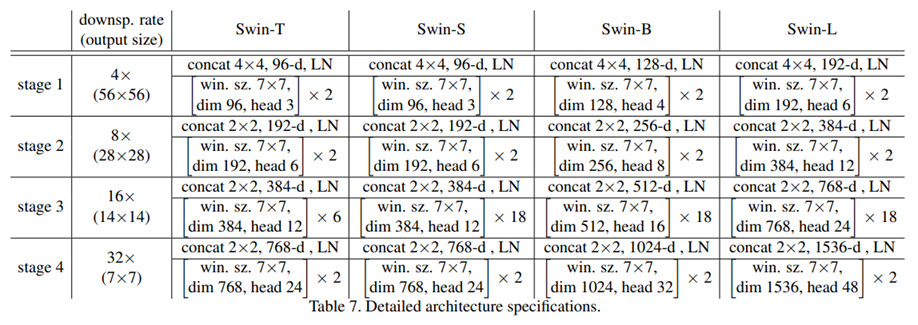

In [70]:
num_classes = 10
embed_dim = 96
mlp_ratio = 4

patch_size = [2, 2]
window_size = [7, 7]

depths = [2, 2]
num_heads = [3, 6]

dropout = 0
attention_dropout = 0
stochastic_depth_prob = 0.1

swin_cuda = SwinTransformer(patch_size, embed_dim, depths, num_heads, window_size, num_classes, mlp_ratio, dropout, attention_dropout, stochastic_depth_prob).to(cuda_device)

In [71]:
swin_cuda

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): LazyConv2d(0, 96, kernel_size=(2, 2), stride=(2, 2))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [72]:
for batch, (X, y) in enumerate(fashion_mnist_train_loader):
    break
output = swin_cuda(X.to(cuda_device))
output

tensor([[-0.0865,  0.3944,  0.0974,  ...,  0.2621, -0.0550,  0.2993],
        [-0.0726,  0.3611,  0.1003,  ...,  0.2754, -0.0487,  0.2738],
        [-0.0861,  0.1972, -0.0084,  ..., -0.0832, -0.0500,  0.2068],
        ...,
        [-0.0694,  0.3122,  0.0795,  ...,  0.2400, -0.0372,  0.2441],
        [-0.0881,  0.2944,  0.0276,  ...,  0.0603, -0.0370,  0.2653],
        [-0.0691,  0.4107,  0.1259,  ...,  0.3748, -0.0487,  0.2920]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [73]:
output.size()

torch.Size([250, 10])

The number of parameters is as follows.

In [74]:
sum(p.numel() for p in swin_cuda.parameters() if p.requires_grad)

1193932

In [75]:
optim_SGD_cuda =  torch.optim.SGD(swin_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[75], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, swin_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3528.3586423397064


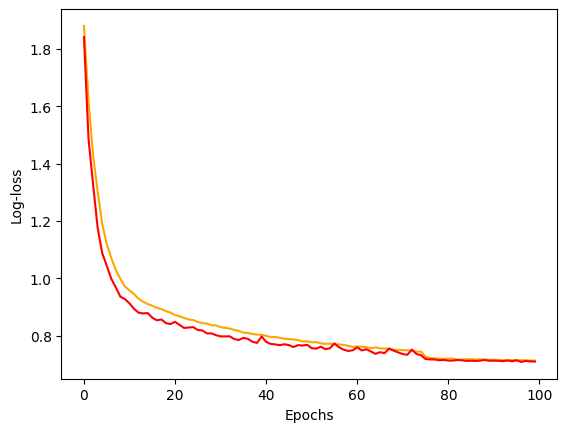

In [76]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

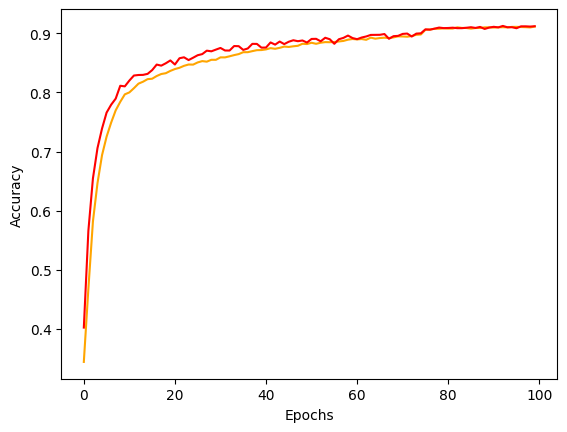

In [77]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

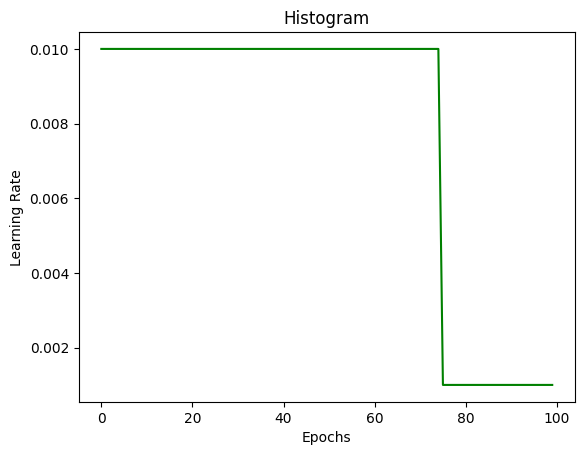

In [78]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [79]:
accu_epochs_train[99]

0.9110333323478699

In [80]:
accu_epochs_test[99]

0.9116999506950378

In [81]:
accu_epochs_test.max()

0.9121999740600586

The Swin transformer model performed a bit better than our vision transformer trained from scratch. The CIFAR-10 dataset is next.

In [82]:
del swin_cuda
torch.cuda.empty_cache()

In [83]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[56,56], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.Resize([56, 56])
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

We went for a slightly bigger model.

In [84]:
num_classes = 10
embed_dim = 96
mlp_ratio = 4

patch_size = [2, 2, 2]
window_size = [7, 7, 7]

depths = [2, 2, 2]
num_heads = [3, 6, 12]

dropout = 0
attention_dropout = 0
stochastic_depth_prob = 0.1


swin_cuda = SwinTransformer(patch_size, embed_dim, depths, num_heads, window_size, num_classes, mlp_ratio, dropout, attention_dropout, stochastic_depth_prob).to(cuda_device)

In [85]:
for batch, (X, y) in enumerate(cifar10_train_loader):
    break
output = swin_cuda(X.to(cuda_device))
output

tensor([[ 0.0372,  0.4717,  0.0967,  ..., -0.3316, -0.1594, -0.0018],
        [-0.0476, -0.0115,  0.4928,  ...,  0.0241,  0.0063, -0.4182],
        [ 0.0095, -0.3646, -0.0916,  ..., -0.1546, -0.0429, -0.2988],
        ...,
        [ 0.0507,  0.0933,  0.0382,  ..., -0.4043, -0.0677,  0.0183],
        [ 0.0136,  0.4246,  0.0633,  ..., -0.2868, -0.1026,  0.1384],
        [ 0.0254, -0.3071, -0.0688,  ..., -0.0387, -0.2546,  0.0042]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [86]:
output.size()

torch.Size([125, 10])

In [87]:
sum(p.numel() for p in swin_cuda.parameters() if p.requires_grad)

5046436

In [88]:
optim_SGD_cuda =  torch.optim.SGD(swin_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[75], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, swin_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3774.909611225128


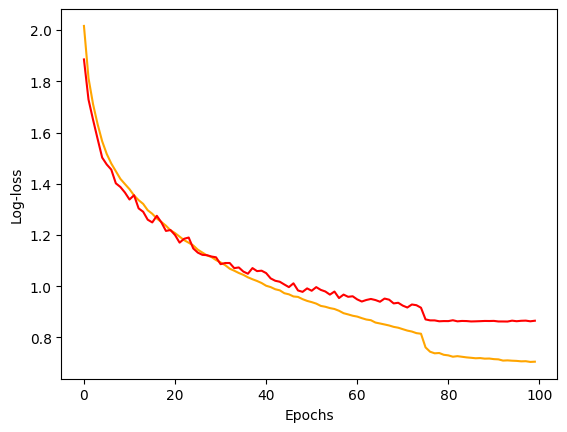

In [89]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

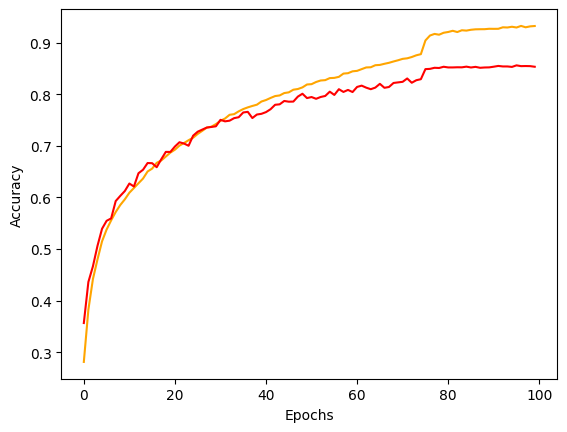

In [90]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

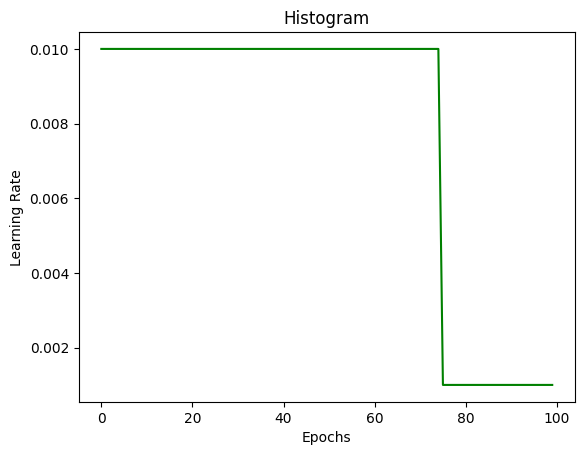

In [91]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [95]:
accu_epochs_train[99]

0.932159960269928

In [96]:
accu_epochs_test[99]

0.8531999588012695

In [97]:
accu_epochs_test.max()

0.85589998960495

The performance of the Swin transformer trained from scratch is much better than that of the vision transformer, demonstrating that the Swin transformer is better suited to smaller datasets.

### Transfer Learning on CIFAR-10 <a class="anchor" id="transfer_learning"></a>

As the last step of this project, let us again use transfer learning on CIFAR-10. Specifically, we will use the Swin transformer https://docs.pytorch.org/vision/main/models/generated/torchvision.models.swin_b.html#torchvision.models.swin_b trained on the ImageNet dataset.

In [98]:
del swin_cuda
torch.cuda.empty_cache()

In [99]:
swin_cuda = torchvision.models.swin_b(weights='IMAGENET1K_V1')

In [100]:
swin_cuda

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock

We need to remember to freeze the model's parameters and replace the final classification layer.

In [101]:
for param in swin_cuda.parameters():
    param.requires_grad = False

In [102]:
swin_cuda.head

Linear(in_features=1024, out_features=1000, bias=True)

In [103]:
swin_cuda.head = nn.Linear(1024,10)

In [104]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[224,224], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.Resize([224,224])
    ]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

In [105]:
for batch, (X, y) in enumerate(cifar10_train_loader):
    break

swin_cuda = swin_cuda.to(cuda_device)
swin_cuda(X.to(cuda_device))

tensor([[ 0.1182,  0.0315, -0.4242,  ...,  0.0629, -0.0760, -0.3347],
        [ 0.1767, -0.2199, -0.1716,  ..., -0.3517, -0.4218, -0.6360],
        [ 0.1384,  0.0353, -0.3028,  ...,  0.2040, -0.1872, -0.3484],
        ...,
        [ 0.2018, -0.1880, -0.4561,  ..., -0.0747, -0.1393, -0.5492],
        [ 0.5817,  0.0102, -0.0243,  ..., -0.3097,  0.0286, -0.2409],
        [ 0.4358, -0.3236, -0.1632,  ..., -0.0249,  0.1750, -0.4448]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [106]:
swin_cuda(X.to(cuda_device)).size()

torch.Size([125, 10])

In [107]:
n_epochs = 50

optim_SGD_cuda =  torch.optim.SGD(swin_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, swin_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

9676.071591615677


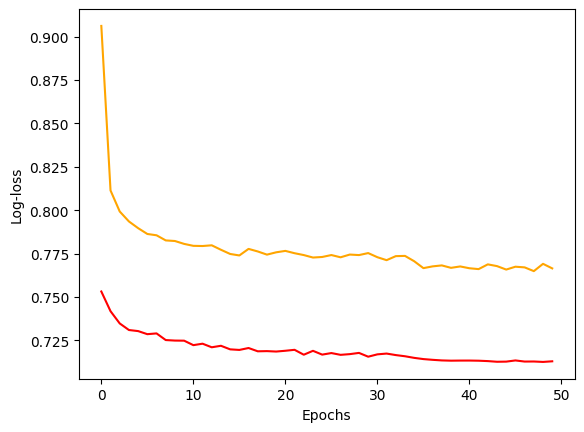

In [108]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

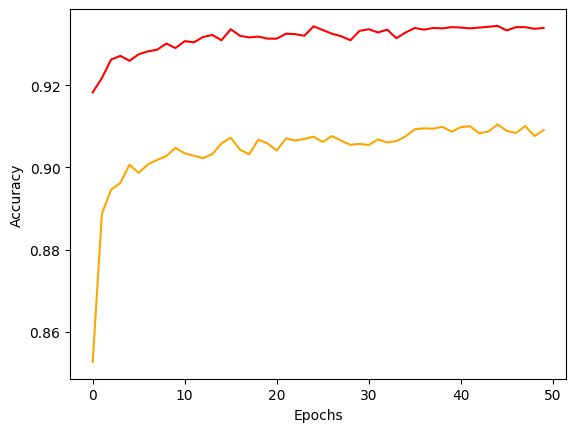

In [109]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

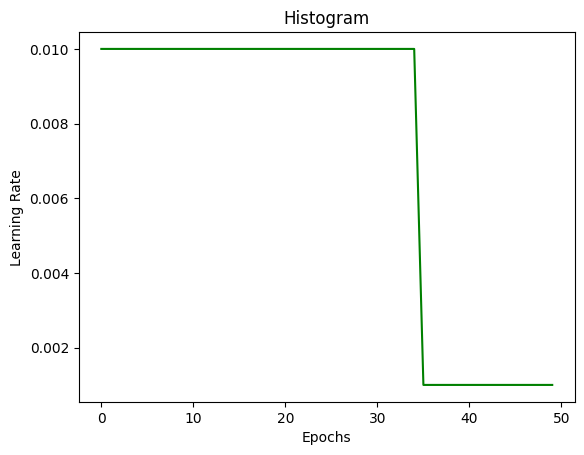

In [110]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [111]:
accu_epochs_train[49]

0.9090999960899353

In [112]:
accu_epochs_test[49]

0.9339999556541443

In [113]:
accu_epochs_test.max()

0.934499979019165

The test set accuracy is pretty decent, but it is significantly lower than the one we have obtained from fine-tuning the vision transformer (96% test set accuracy).  

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> DOSOVITSKIY, Alexey, et al. An image is worth 16x16 words: Transformers for image recognition at scale. arXiv preprint arXiv:2010.11929, 2020.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="3">[3]</a> LIU, Ze, et al. Swin transformer: Hierarchical vision transformer using shifted windows. In: *Proceedings of the IEEE/CVF international conference on computer vision.* 2021. p. 10012-10022.

<a id="4">[4]</a> HUANG, Gao, et al. Deep networks with stochastic depth. In: European conference on computer vision. Cham: Springer International Publishing, 2016. p. 646-661.

<a id="5">[5]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.